In [1]:
import numpy as np
import pandas as pd
import math

import seaborn as sns
import matplotlib.pyplot as plt


ref_genome_folder = 'ref_genome/hg19'
exclude_chr = ['chrM', 'chrY']
resolution = 50000


# load ref genome length info
chr_length = dict()
with open(ref_genome_folder + '/hg19.len', 'r') as f:
    lines = f.read().splitlines()
    for line in lines:
        chr_name , len_ = line.split('\t')[:2]
        if chr_name in exclude_chr:
            continue
        chr_length[chr_name] = int(len_)
print('chr length : \n',chr_length)

# calculate bin number in each chr
chr_bin_number = dict()
for key in chr_length.keys():
    chr_bin_number[key] = math.floor(chr_length[key] / resolution) + 1
print('chr bin number : \n', chr_bin_number)

chr length : 
 {'chr1': 249250621, 'chr2': 243199373, 'chr3': 198022430, 'chr4': 191154276, 'chr5': 180915260, 'chr6': 171115067, 'chr7': 159138663, 'chr8': 146364022, 'chr9': 141213431, 'chr10': 135534747, 'chr11': 135006516, 'chr12': 133851895, 'chr13': 115169878, 'chr14': 107349540, 'chr15': 102531392, 'chr16': 90354753, 'chr17': 81195210, 'chr18': 78077248, 'chr19': 59128983, 'chr20': 63025520, 'chr21': 48129895, 'chr22': 51304566, 'chrX': 155270560}
chr bin number : 
 {'chr1': 4986, 'chr2': 4864, 'chr3': 3961, 'chr4': 3824, 'chr5': 3619, 'chr6': 3423, 'chr7': 3183, 'chr8': 2928, 'chr9': 2825, 'chr10': 2711, 'chr11': 2701, 'chr12': 2678, 'chr13': 2304, 'chr14': 2147, 'chr15': 2051, 'chr16': 1808, 'chr17': 1624, 'chr18': 1562, 'chr19': 1183, 'chr20': 1261, 'chr21': 963, 'chr22': 1027, 'chrX': 3106}


In [2]:
bin_dict = dict()
bin_dict['chr1'] = np.zeros(chr_bin_number['chr1'])

with open('K562_WGS_CNV/chr1.bin', 'r') as f:
    for line in f.readlines()[1:]:
        start_, end_, obs, exps, var = line.strip().split()
        start_bin = math.floor(int(start_) / resolution)
        if (float(obs) <= 0) or (float(exps) <= 0):
            log2_ratio = 0
        else:
            log2_ratio = math.log2(float(obs)/float(exps))
        bin_dict['chr1'][start_bin] = log2_ratio

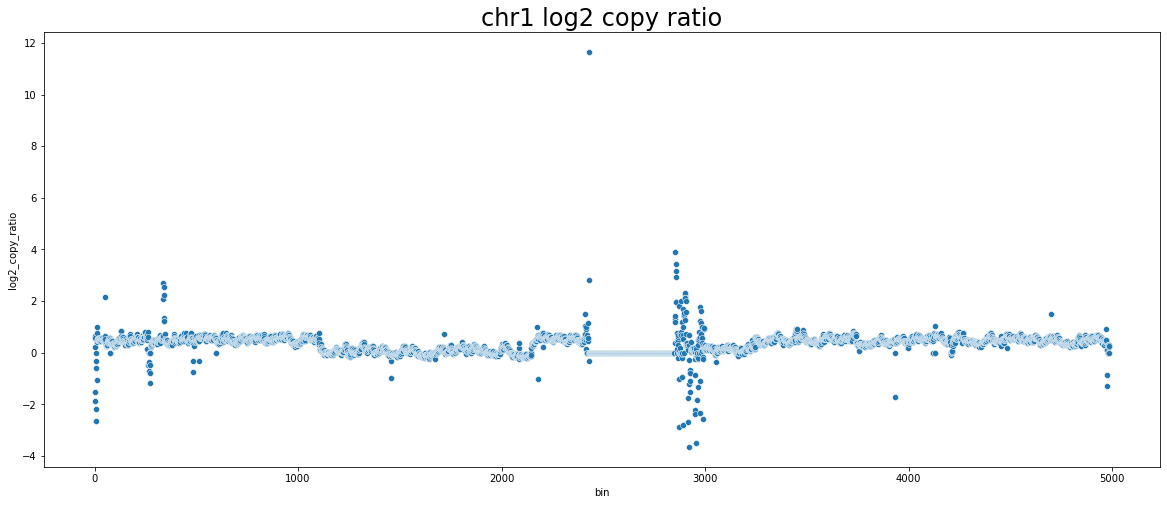

In [3]:
df_for_plot = pd.DataFrame( np.array([np.arange(0,chr_bin_number['chr1'],1, dtype = 'int'),bin_dict['chr1']]).transpose(), columns=['bin','log2_copy_ratio'])

fig,ax = plt.subplots(1,1)
fig.set_size_inches((20,8))
ax.set_title('chr1 log2 copy ratio', fontsize = 24)
sns.scatterplot(data=df_for_plot, x="bin", y="log2_copy_ratio")

#### with removing outlier

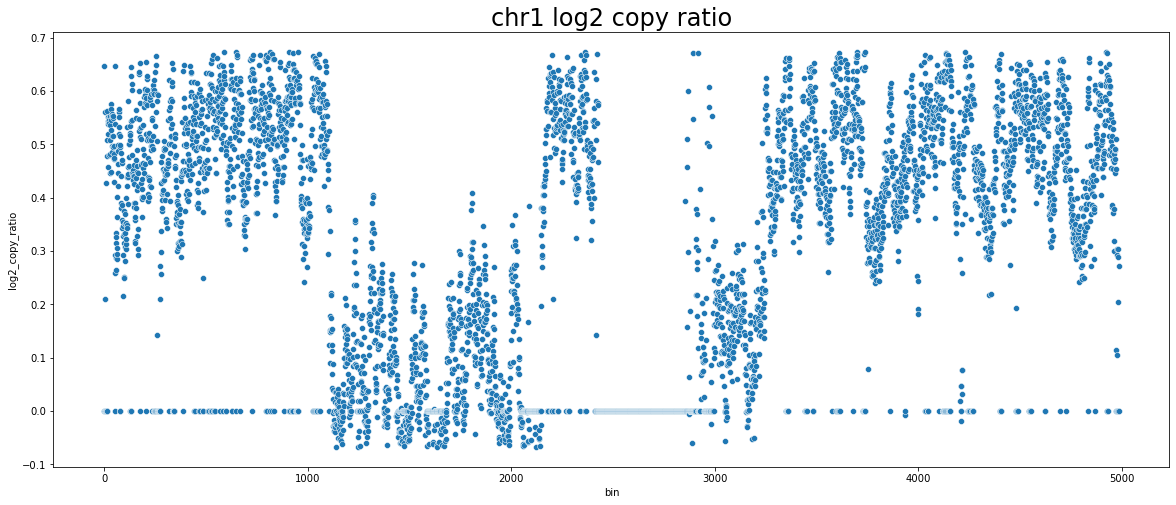

In [4]:
upper_cut_point = np.percentile(bin_dict['chr1'], 95)
lower_cut_point = np.percentile(bin_dict['chr1'], 5)
for i in range(len(bin_dict['chr1'])):
    if (bin_dict['chr1'][i] >= upper_cut_point) or (bin_dict['chr1'][i] <= lower_cut_point):
        bin_dict['chr1'][i] = 0

df_for_plot = pd.DataFrame( np.array([np.arange(0,chr_bin_number['chr1'],1, dtype = 'int'),bin_dict['chr1']]).transpose(), columns=['bin','log2_copy_ratio'])

fig,ax = plt.subplots(1,1)
fig.set_size_inches((20,8))
ax.set_title('chr1 log2 copy ratio', fontsize = 24)
sns.scatterplot(data=df_for_plot, x="bin", y="log2_copy_ratio")